In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import fftconvolve
from PIL import Image
import IPython.display as ipd
import io

# Lista 2 - Visão Computacional

---

## Questão 1 — Áudio

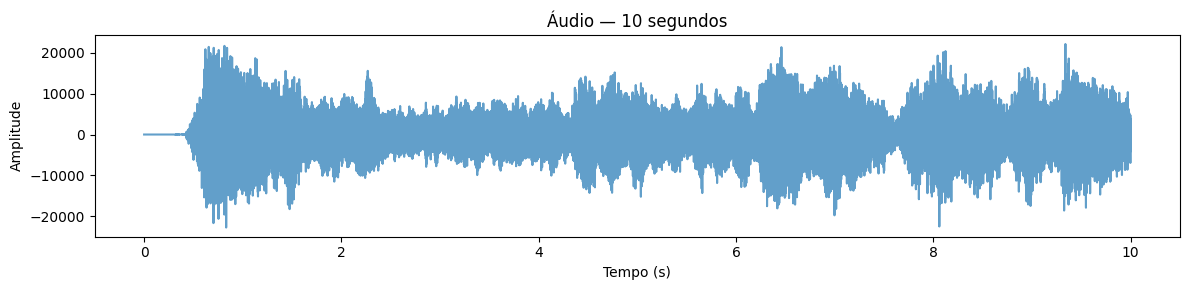

In [2]:
# (a) Leitura e corte para 10 segundos
sw_freq, sw_data = wavfile.read('StarWars60.wav')

# Converte para mono se for estéreo
if sw_data.ndim > 1:
    sw_data = sw_data[:, 0]

seg_10 = sw_freq * 10
sw_10seg = sw_data[:seg_10].astype(np.float64)

t = np.linspace(0, 10, seg_10)
plt.figure(figsize=(12, 3))
plt.plot(t, sw_10seg, alpha=0.7)
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title('Áudio — 10 segundos')
plt.tight_layout()
plt.show()

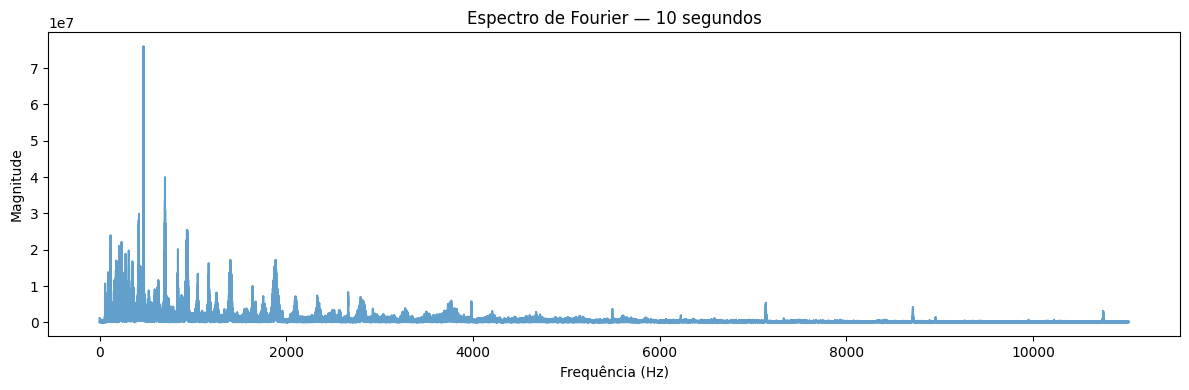

In [3]:
# (b) Espectro do áudio de 10 segundos
coef = np.fft.fft(sw_10seg)
coef_magnitude = np.abs(coef)
frequencias = np.fft.fftfreq(len(sw_10seg), d=1/sw_freq)

metade = len(sw_10seg) // 2
plt.figure(figsize=(12, 4))
plt.plot(frequencias[:metade], coef_magnitude[:metade], alpha=0.7)
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.title('Espectro de Fourier — 10 segundos')
plt.tight_layout()
plt.show()

# Reprodução (requer sounddevice instalado)
# import sounddevice as sd
# sd.play(sw_10seg, sw_freq); sd.wait()

# Alternativa com IPython
audio_norm = sw_10seg / np.max(np.abs(sw_10seg))
ipd.display(ipd.Audio(audio_norm, rate=sw_freq))

---

## Questão 2 — Compressão com Fourier

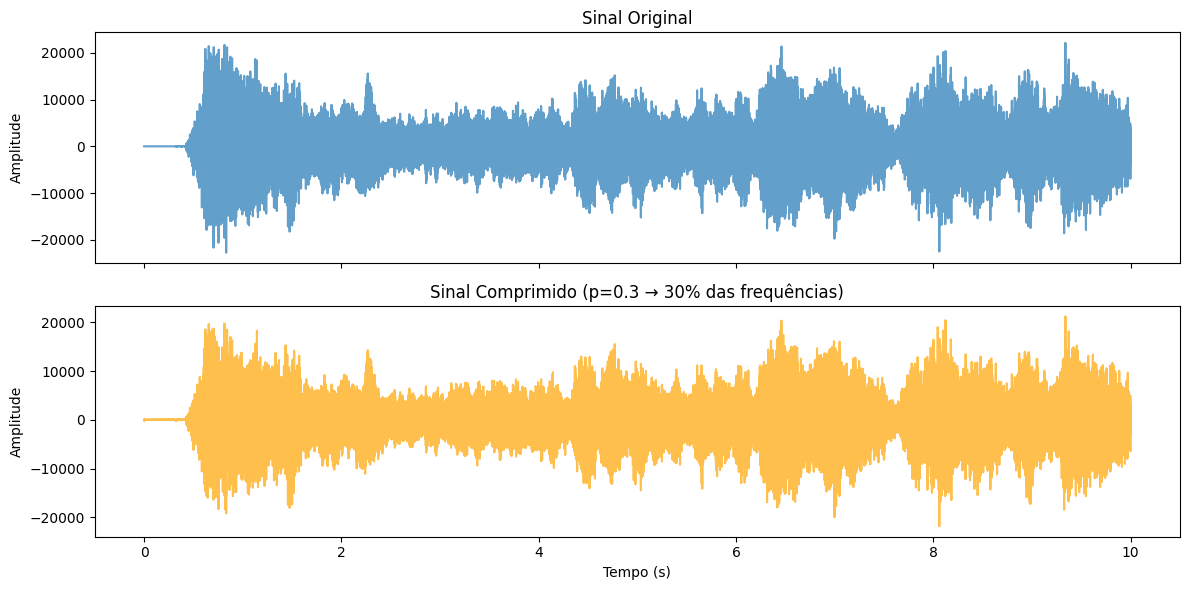

In [4]:
# (a) Compressão: zeramos as frequências ALTAS, mantemos apenas p*100% das baixas

def comprime_audio(sinal, p):
    """
    Comprime o sinal zerando as frequências altas.
    p in [0,1]: fração das frequências BAIXAS que são mantidas.
    Exemplo: p=0.5 -> mantém os 50% centrais de frequências baixas.
    """
    N = len(sinal)
    coef = np.fft.fft(sinal)
    # Quantas amostras de baixa freq manter de cada lado
    n_manter = int(N * p / 2)
    coef_comprimido = np.zeros_like(coef)
    coef_comprimido[:n_manter] = coef[:n_manter]          # baixas positivas
    coef_comprimido[N - n_manter:] = coef[N - n_manter:]  # baixas negativas (simetria)
    sinal_reconstruido = np.fft.ifft(coef_comprimido).real
    return sinal_reconstruido, coef_comprimido

# Testamos com p = 0.30 (mantém 30% das frequências)
p = 0.30
sw_comprimido, coef_comp = comprime_audio(sw_10seg, p)

# Comparação visual
t = np.linspace(0, 10, seg_10)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t, sw_10seg, alpha=0.7, label='Original')
axes[0].set_title('Sinal Original')
axes[0].set_ylabel('Amplitude')
axes[1].plot(t, sw_comprimido, alpha=0.7, color='orange', label=f'Comprimido (p={p})')
axes[1].set_title(f'Sinal Comprimido (p={p} → {p*100:.0f}% das frequências)')
axes[1].set_xlabel('Tempo (s)')
axes[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [ ]:
# (b) Diferença perceptual + SNR

def snr(original, reconstruido):
    """Signal-to-Noise Ratio em dB."""
    ruido = original - reconstruido
    pot_sinal = np.mean(original ** 2)
    pot_ruido  = np.mean(ruido ** 2)
    if pot_ruido == 0:
        return np.inf
    return 10 * np.log10(pot_sinal / pot_ruido)

# Testamos vários valores de p
ps = [0.80, 0.50, 0.30, 0.10]
print(f"{'p':>6}  {'SNR (dB)':>10}")
print('-' * 20)
for p_val in ps:
    rec, _ = comprime_audio(sw_10seg, p_val)
    s = snr(sw_10seg, rec)
    print(f"{p_val:>6.2f}  {s:>10.2f}")

print()
print("""Análise:
- Com p alto (80%), o SNR é alto e a diferença perceptual é mínima.
- Conforme p diminui, o SNR cai e o áudio fica mais "abafado" / sem
  altos — as frequências altas (agudos) são descartadas.
- Com p muito baixo (10%), o áudio soa muito diferente do original.
""")

# Reprodução do comprimido (p=0.30)
p = 0.30
sw_comp_30, _ = comprime_audio(sw_10seg, p)
audio_comp = sw_comp_30 / np.max(np.abs(sw_comp_30))
print(f"Áudio comprimido (p={p}):")
ipd.display(ipd.Audio(audio_comp, rate=sw_freq))

---

## Questão 3 — Convolução em sinais de áudio com Fourier

In [ ]:
# Utilitário: aplica convolução via FFT
def aplica_filtro(sinal, h):
    """Convolução linear via FFT (usa comprimento adequado para evitar aliasing)."""
    resultado = fftconvolve(sinal, h, mode='full')
    # Trunca para o tamanho original
    return resultado[:len(sinal)]

In [ ]:
# (a) Eco simples: h[n] = delta[n] + ganho * delta[n - delay_amostras]

delay_s   = 0.5          # 0,5 segundos
ganho_eco = 0.4          # ganho do eco

delay_amostras = int(sw_freq * delay_s)

# Filtro de eco
h_eco = np.zeros(delay_amostras + 1)
h_eco[0]              = 1.0        # sinal original
h_eco[delay_amostras] = ganho_eco  # eco

sw_eco = aplica_filtro(sw_10seg, h_eco)

# Normaliza para reprodução
audio_eco = sw_eco / np.max(np.abs(sw_eco))

print(f"Filtro de eco: delay={delay_s}s, ganho={ganho_eco}")
print("Tamanho do filtro h:", len(h_eco), "amostras")
print()
print("Áudio com eco:")
ipd.display(ipd.Audio(audio_eco, rate=sw_freq))

# Visualização
t_plot = np.linspace(0, 10, len(sw_eco))
plt.figure(figsize=(12, 3))
plt.plot(t_plot, sw_eco, alpha=0.7, color='green')
plt.title('Sinal com Eco (0,5 s, ganho=0,4)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [ ]:
# (b) Reverb: múltiplos ecos com amplitude decrescente

n_ecos       = 10          # número de ecos
delay_ms     = 40          # delay entre ecos (ms)
ganho_inicial = 0.5        # ganho do primeiro eco
decaimento    = 0.7        # fator de decaimento por eco

delay_rev = int(sw_freq * delay_ms / 1000)

# O filtro tem comprimento: 1 + n_ecos * delay_rev
h_reverb = np.zeros(1 + n_ecos * delay_rev)
h_reverb[0] = 1.0  # sinal direto

ganho_atual = ganho_inicial
for i in range(1, n_ecos + 1):
    h_reverb[i * delay_rev] = ganho_atual
    ganho_atual *= decaimento

sw_reverb = aplica_filtro(sw_10seg, h_reverb)

# Normaliza
audio_reverb = sw_reverb / np.max(np.abs(sw_reverb))

print(f"Filtro reverb: {n_ecos} ecos, delay={delay_ms}ms, "
      f"ganho inicial={ganho_inicial}, decaimento={decaimento}")
print()
print("Áudio com reverb:")
ipd.display(ipd.Audio(audio_reverb, rate=sw_freq))

# Visualização do filtro h
t_h = np.arange(len(h_reverb)) / sw_freq * 1000  # em ms
plt.figure(figsize=(12, 3))
plt.stem(t_h, h_reverb, markerfmt='C1o', linefmt='C1-', basefmt='k-')
plt.title('Resposta ao Impulso — Filtro Reverb')
plt.xlabel('Tempo (ms)')
plt.ylabel('Ganho')
plt.tight_layout()
plt.show()

---

## Questão 4 — Compressão de imagem com Fourier

In [ ]:
# Carrega a imagem
img = np.array(Image.open('frutas.jpg').convert('L'), dtype=np.float64)

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title('Imagem Original (escala de cinza)')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Tamanho: {img.shape}")

In [ ]:
# Funções auxiliares

def mascara_passabaixa(shape, p):
    """Máscara circular de passa-baixa: mantém p*100% das frequências (as mais baixas)."""
    H, W = shape
    cy, cx = H // 2, W // 2
    # Raio em pixels proporcional a p
    r = p * min(H, W) / 2
    y, x = np.ogrid[:H, :W]
    dist = np.sqrt((y - cy)**2 + (x - cx)**2)
    return (dist <= r).astype(float)

def comprime_imagem(imagem, p, passa_alta=False):
    """
    Comprime a imagem no domínio da frequência.
    p: fração das frequências mantidas.
    passa_alta=False -> passa-baixa (mantém baixas freq).
    passa_alta=True  -> passa-alta (mantém altas freq).
    """
    F = np.fft.fft2(imagem)
    F_shift = np.fft.fftshift(F)   # coloca DC no centro
    mask = mascara_passabaixa(imagem.shape, p)
    if passa_alta:
        mask = 1 - mask
    F_filtrado = F_shift * mask
    F_ishift   = np.fft.ifftshift(F_filtrado)
    img_rec    = np.fft.ifft2(F_ishift).real
    return img_rec, mask

def psnr(original, reconstruida):
    """PSNR em dB (escala 0–255)."""
    mse = np.mean((original - reconstruida) ** 2)
    if mse == 0:
        return np.inf
    return 10 * np.log10(255**2 / mse)

def mse(original, reconstruida):
    return np.mean((original - reconstruida) ** 2)

In [ ]:
# (a) + (b) Passa-baixa: diferentes valores de p

ps = [0.80, 0.50, 0.30, 0.10]

fig, axes = plt.subplots(1, len(ps) + 1, figsize=(15, 4))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

print(f"{'p':>6}  {'MSE':>10}  {'PSNR (dB)':>12}")
print('-' * 32)

for i, p_val in enumerate(ps):
    rec, _ = comprime_imagem(img, p_val)
    rec_clip = np.clip(rec, 0, 255)
    m = mse(img, rec_clip)
    s = psnr(img, rec_clip)
    print(f"{p_val:>6.2f}  {m:>10.2f}  {s:>12.2f}")
    axes[i+1].imshow(rec_clip, cmap='gray', vmin=0, vmax=255)
    axes[i+1].set_title(f'p={p_val}\nPSNR={s:.1f}dB')
    axes[i+1].axis('off')

plt.suptitle('Compressão Passa-Baixa — Imagem Reconstruída', fontsize=13)
plt.tight_layout()
plt.show()

print()
print("""Análise (passa-baixa):
- Com p alto (ex: 80%), a imagem reconstruída é muito similar ao original.
- Ao reduzir p, bordas e detalhes finos desaparecem; a imagem fica 'borrada'.
- Com p muito baixo (10%), apenas contornos grosseiros são visíveis.
- Numericamente: MSE cresce e PSNR cai conforme p diminui.
""")

In [ ]:
# (c) Passa-alta: descartamos as frequências baixas, mantemos as altas

ps_alta = [0.80, 0.50, 0.30, 0.10]

fig, axes = plt.subplots(1, len(ps_alta) + 1, figsize=(15, 4))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

for i, p_val in enumerate(ps_alta):
    rec, _ = comprime_imagem(img, p_val, passa_alta=True)
    # Centraliza em 128 para visualizar (valores podem ser negativos/muito baixos)
    rec_vis = rec - rec.min()
    rec_vis = rec_vis / rec_vis.max() * 255
    axes[i+1].imshow(rec_vis, cmap='gray')
    axes[i+1].set_title(f'Passa-Alta\np={p_val}')
    axes[i+1].axis('off')

plt.suptitle('Filtro Passa-Alta — Efeito nas Imagens', fontsize=13)
plt.tight_layout()
plt.show()

print("""Análise (passa-alta):
- O filtro passa-alta remove as componentes de baixa frequência (luminância
  média, gradientes suaves).
- O resultado é uma imagem que realça bordas, texturas e detalhes finos.
- Com p grande (descartar muitas frequências baixas), sobram apenas as
  bordas mais abruptas — efeito de 'detecção de bordas'.
- Diferentemente da passa-baixa, a imagem NÃO se parece com o original:
  ela mostra contrastes locais, não a cena inteira.
""")

---

## Questão 5 — Convolução Circular e o Impulso

**Enunciado:** Mostre que $h = T(\delta)$, onde $\delta = (1, 0, 0, \ldots, 0)$.

**Demonstração:**

Todo vetor $u \in \mathbb{R}^n$ pode ser escrito na base canônica:
$$
u = \sum_{k=0}^{n-1} u_k\, e_k
$$
onde $e_k$ é o $k$-ésimo vetor da base ($e_k[j] = 1$ se $j=k$, 0 caso contrário).

Note que $e_k$ é uma **translação circular** de $\delta = e_0$:
$$
e_k[j] = \delta[j - k \mod n]
$$

Como $T$ é **linear** e **invariante por translação**:
$$
T(u) = T\!\left(\sum_k u_k e_k\right)
= \sum_k u_k T(e_k)         \quad (\text{linearidade})
= \sum_k u_k T(\delta(\cdot - k)) \quad (e_k \text{ é translação de } \delta)
= \sum_k u_k [T(\delta)](\cdot - k) \quad (\text{invariância por translação})
$$

Definindo $h = T(\delta)$, temos:
$$
T(u)[j] = \sum_k u_k\, h[j - k \mod n] = (h \circledast u)[j]
$$

Ou seja, $T(u) = h \circledast u$, e $h$ é obtido aplicando $T$ ao impulso $\delta$. $\blacksquare$

---

## Questão 6 — Filtro Linear e Invariante por Translação é Convolução Circular

**Enunciado:** Mostre que qualquer $F : \mathbb{R}^n \to \mathbb{R}^n$ linear e invariante por translação circular é uma convolução circular.

**Demonstração:**

A prova é análoga à Q5.  
Como $F$ é linear e todo vetor $u$ se decompõe na base canônica:
$$
F(u) = \sum_{k=0}^{n-1} u_k\, F(e_k)
$$

Pela invariância por translação circular, se $F(e_0) = h$, então
$$
F(e_k) = h(\cdot - k)
$$

Portanto:
$$
F(u)[j] = \sum_{k=0}^{n-1} u_k\, h[j - k \mod n] = (h \circledast u)[j]
$$

Logo $F$ é a convolução circular com o núcleo $h = F(\delta)$. $\blacksquare$